# Arquitecturas CNN VAE
Visualización de VAE3D (v1) y VAE3DDeep (deep)

In [9]:
import sys
sys.path.insert(0, '../src')
import torch
from model import VAE3D, VAE3DDeep

LATENT_CH = 64
x = torch.zeros(1, 1, 224, 224, 10)

---
## VAE3D - v1
2 bloques encoder con stride-4, kernel-5.

In [10]:
v1 = VAE3D(latent_ch=LATENT_CH).eval()

n_enc = sum(p.numel() for p in v1.encoder.parameters())
n_dec = sum(p.numel() for p in v1.decoder.parameters())
n_tot = sum(p.numel() for p in v1.parameters())
print(f'Encoder: {n_enc:,} params')
print(f'Decoder: {n_dec:,} params')
print(f'Total:   {n_tot:,} params')
print()
print(v1)

Encoder: 268,608 params
Decoder: 264,257 params
Total:   532,865 params

VAE3D(
  (encoder): Encoder(
    (convs): Sequential(
      (0): Sequential(
        (0): Conv3d(1, 32, kernel_size=(5, 5, 5), stride=(4, 4, 4), padding=(2, 2, 2))
        (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Dropout3d(p=0.1, inplace=False)
        (3): LeakyReLU(negative_slope=0.2, inplace=True)
      )
      (1): Sequential(
        (0): Conv3d(32, 64, kernel_size=(5, 5, 5), stride=(4, 4, 4), padding=(2, 2, 2))
        (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Dropout3d(p=0.1, inplace=False)
        (3): LeakyReLU(negative_slope=0.2, inplace=True)
      )
    )
    (conv_mu): Conv3d(64, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1))
    (conv_lv): Conv3d(64, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1))
  )
  (decoder): Decoder(
    (conv_in): Conv3d(64, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1))
 

In [11]:
print('=== Shape trace VAE3D (v1) ===')
print(f'Input:              {tuple(x.shape)}')

h = x
for i, layer in enumerate(v1.encoder.convs):
    h = layer(h)
    print(f'Encoder bloque {i}:   {tuple(h.shape)}')

mu = v1.encoder.conv_mu(h)
lv = v1.encoder.conv_lv(h)
print(f'mu / log_var:       {tuple(mu.shape)}   <- espacio latente')

z = v1.decoder.conv_in(mu)
print(f'Decoder conv_in:    {tuple(z.shape)}')
for i, layer in enumerate(v1.decoder.convs):
    z = layer(z)
    print(f'Decoder bloque {i}:   {tuple(z.shape)}')
print(f'Output:             {tuple(z.shape)}')

=== Shape trace VAE3D (v1) ===
Input:              (1, 1, 224, 224, 10)
Encoder bloque 0:   (1, 32, 56, 56, 3)
Encoder bloque 1:   (1, 64, 14, 14, 1)
mu / log_var:       (1, 64, 14, 14, 1)   <- espacio latente
Decoder conv_in:    (1, 64, 14, 14, 1)
Decoder bloque 0:   (1, 32, 56, 56, 3)
Decoder bloque 1:   (1, 1, 224, 224, 10)
Output:             (1, 1, 224, 224, 10)


---
## VAE3DDeep - deep
4 bloques encoder con stride-2, kernel-3. Compresión gradual.

In [12]:
deep = VAE3DDeep(latent_ch=LATENT_CH).eval()

n_enc = sum(p.numel() for p in deep.encoder.parameters())
n_dec = sum(p.numel() for p in deep.decoder.parameters())
n_tot = sum(p.numel() for p in deep.parameters())
print(f'Encoder: {n_enc:,} params')
print(f'Decoder: {n_dec:,} params')
print(f'Total:   {n_tot:,} params')
print()
print(deep)

Encoder: 307,968 params
Decoder: 299,393 params
Total:   607,361 params

VAE3DDeep(
  (encoder): EncoderDeep(
    (convs): Sequential(
      (0): Sequential(
        (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
        (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Dropout3d(p=0.1, inplace=False)
        (3): LeakyReLU(negative_slope=0.2, inplace=True)
      )
      (1): Sequential(
        (0): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
        (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Dropout3d(p=0.1, inplace=False)
        (3): LeakyReLU(negative_slope=0.2, inplace=True)
      )
      (2): Sequential(
        (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
        (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Dropout3d(p=0.1, inpl

In [13]:
print('=== Shape trace VAE3DDeep (deep) ===')
print(f'Input:              {tuple(x.shape)}')

h = x
for i, layer in enumerate(deep.encoder.convs):
    h = layer(h)
    print(f'Encoder bloque {i}:   {tuple(h.shape)}')

mu = deep.encoder.conv_mu(h)
lv = deep.encoder.conv_lv(h)
print(f'mu / log_var:       {tuple(mu.shape)}   <- espacio latente')

z = deep.decoder.conv_in(mu)
print(f'Decoder conv_in:    {tuple(z.shape)}')
for i, layer in enumerate(deep.decoder.convs):
    z = layer(z)
    print(f'Decoder bloque {i}:   {tuple(z.shape)}')
print(f'Output:             {tuple(z.shape)}')

=== Shape trace VAE3DDeep (deep) ===
Input:              (1, 1, 224, 224, 10)
Encoder bloque 0:   (1, 16, 112, 112, 5)
Encoder bloque 1:   (1, 32, 56, 56, 3)
Encoder bloque 2:   (1, 64, 28, 28, 2)
Encoder bloque 3:   (1, 128, 14, 14, 1)
mu / log_var:       (1, 64, 14, 14, 1)   <- espacio latente
Decoder conv_in:    (1, 128, 14, 14, 1)
Decoder bloque 0:   (1, 64, 28, 28, 2)
Decoder bloque 1:   (1, 32, 56, 56, 3)
Decoder bloque 2:   (1, 16, 112, 112, 5)
Decoder bloque 3:   (1, 1, 224, 224, 10)
Output:             (1, 1, 224, 224, 10)


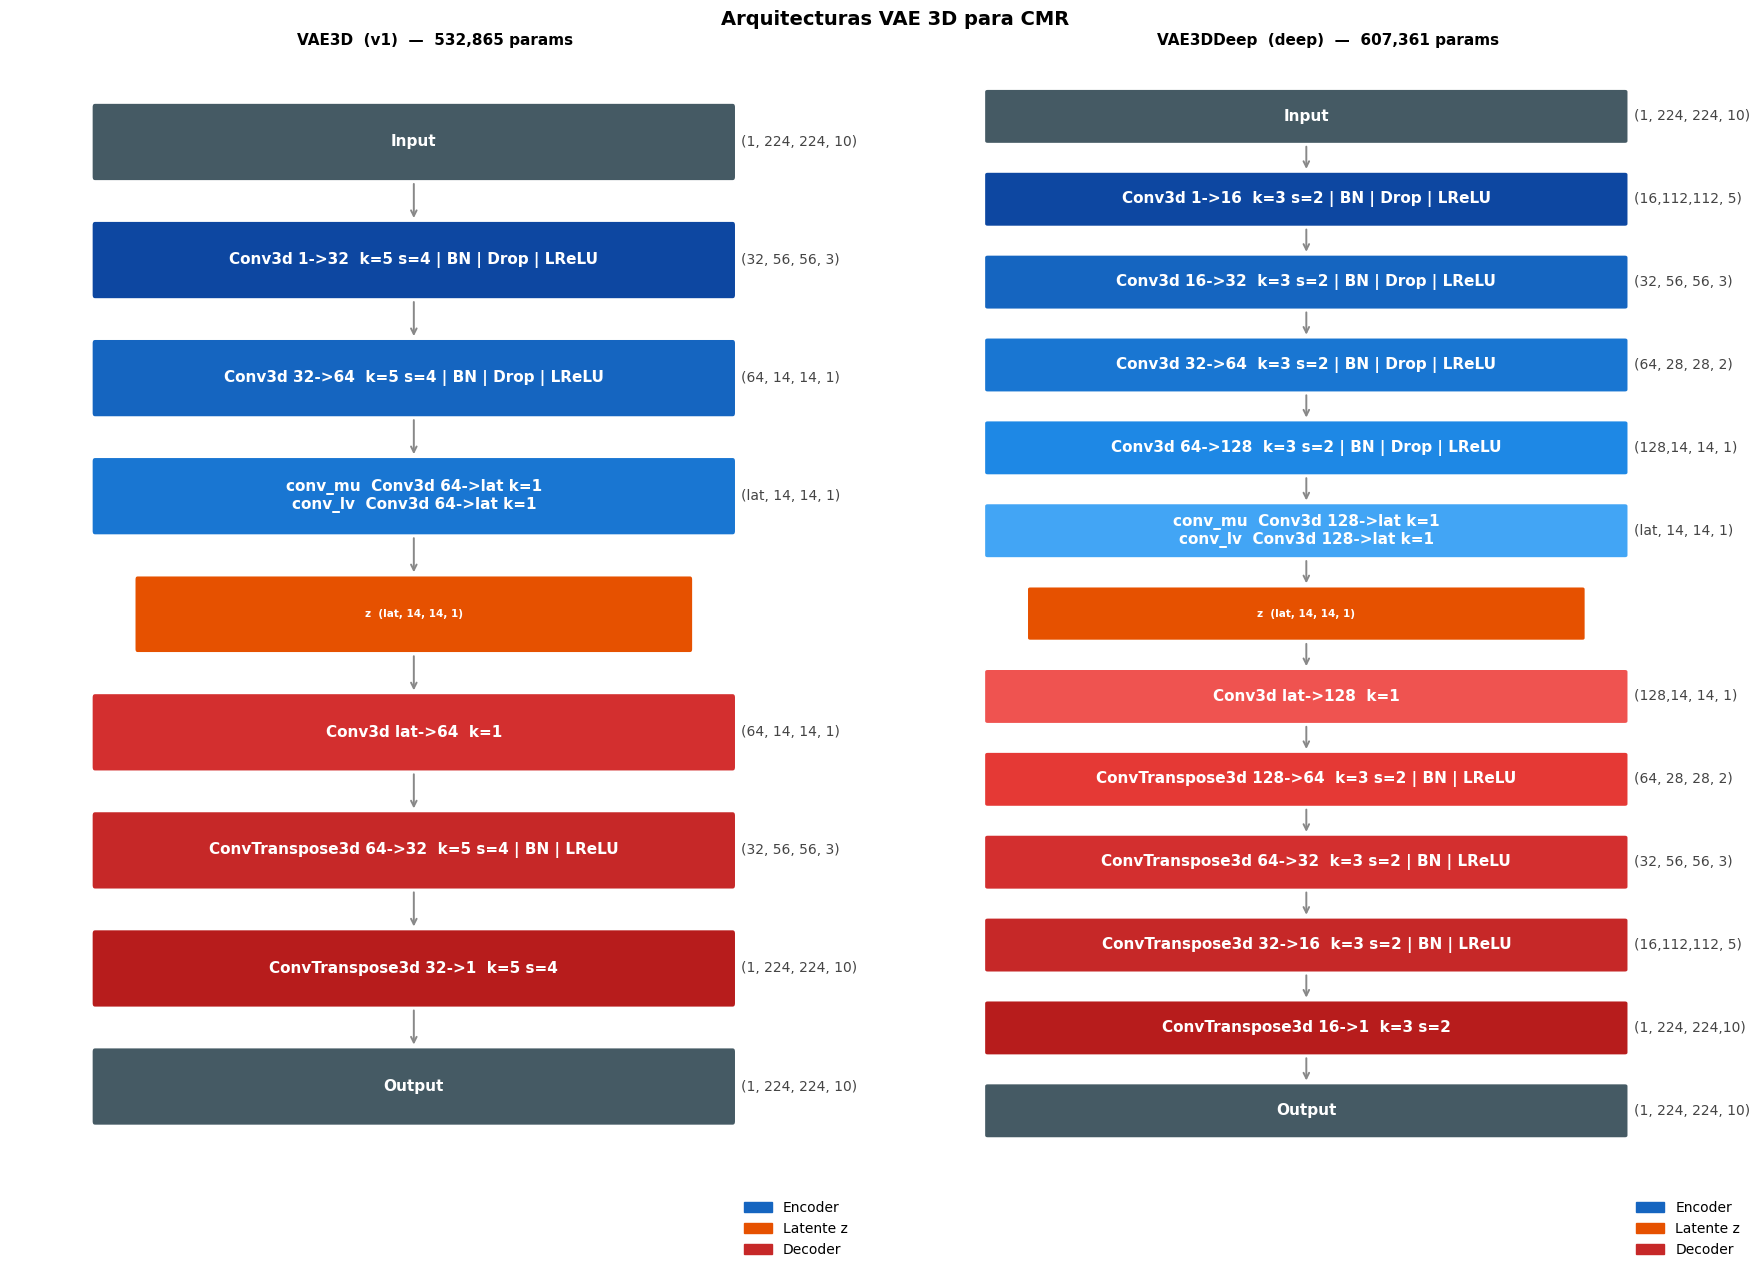

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_vae(ax, title, blocks_enc, blocks_dec, lat_label):
    n_rows = 1 + len(blocks_enc) + 1 + len(blocks_dec) + 1
    ax.set_xlim(0, 10)
    ax.set_ylim(-0.5, n_rows * 1.2)
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

    box_h, box_w, x0 = 0.65, 7.5, 1.0
    y = n_rows * 1.2 - 0.8

    def box(y, label, shape, color):
        ax.add_patch(mpatches.FancyBboxPatch(
            (x0, y - box_h/2), box_w, box_h,
            boxstyle='round,pad=0.04',
            facecolor=color, edgecolor='white', linewidth=1.5))
        ax.text(x0 + box_w/2, y, label, ha='center', va='center',
                fontsize=11, fontweight='bold', color='white')
        ax.text(x0 + box_w + 0.1, y, shape, ha='left', va='center',
                fontsize=10, color='#444444')

    def arrow(y_top, y_bot):
        ax.annotate('', xy=(x0 + box_w/2, y_bot + box_h/2 + 0.04),
                    xytext=(x0 + box_w/2, y_top - box_h/2 - 0.04),
                    arrowprops=dict(arrowstyle='->', color='#888', lw=1.4))

    box(y, 'Input', '(1, 224, 224, 10)', '#455a64'); y -= 1.1
    for lbl, shp, col in blocks_enc:
        arrow(y + 1.1, y); box(y, lbl, shp, col); y -= 1.1
    # latente
    arrow(y + 1.1, y)
    ax.add_patch(mpatches.FancyBboxPatch(
        (x0 + 0.5, y - box_h/2), box_w - 1, box_h,
        boxstyle='round,pad=0.04',
        facecolor='#e65100', edgecolor='white', linewidth=2))
    ax.text(x0 + box_w/2, y, lat_label, ha='center', va='center',
            fontsize=7.5, fontweight='bold', color='white')
    y -= 1.1
    for lbl, shp, col in blocks_dec:
        arrow(y + 1.1, y); box(y, lbl, shp, col); y -= 1.1
    arrow(y + 1.1, y)
    box(y, 'Output', '(1, 224, 224, 10)', '#455a64')

ENC = ['#0d47a1','#1565c0','#1976d2','#1e88e5','#42a5f5']
DEC = ['#b71c1c','#c62828','#d32f2f','#e53935','#ef5350']

enc_v1 = [
    ('Conv3d 1->32  k=5 s=4 | BN | Drop | LReLU',  '(32, 56, 56, 3)',   ENC[0]),
    ('Conv3d 32->64  k=5 s=4 | BN | Drop | LReLU', '(64, 14, 14, 1)',   ENC[1]),
    ('conv_mu  Conv3d 64->lat k=1\nconv_lv  Conv3d 64->lat k=1', '(lat, 14, 14, 1)', ENC[2]),
]
dec_v1 = [
    ('Conv3d lat->64  k=1',                          '(64, 14, 14, 1)',   DEC[2]),
    ('ConvTranspose3d 64->32  k=5 s=4 | BN | LReLU','(32, 56, 56, 3)',   DEC[1]),
    ('ConvTranspose3d 32->1  k=5 s=4',               '(1, 224, 224, 10)', DEC[0]),
]
enc_deep = [
    ('Conv3d 1->16  k=3 s=2 | BN | Drop | LReLU',   '(16,112,112, 5)',  ENC[0]),
    ('Conv3d 16->32  k=3 s=2 | BN | Drop | LReLU',  '(32, 56, 56, 3)',  ENC[1]),
    ('Conv3d 32->64  k=3 s=2 | BN | Drop | LReLU',  '(64, 28, 28, 2)',  ENC[2]),
    ('Conv3d 64->128  k=3 s=2 | BN | Drop | LReLU', '(128,14, 14, 1)',  ENC[3]),
    ('conv_mu  Conv3d 128->lat k=1\nconv_lv  Conv3d 128->lat k=1', '(lat, 14, 14, 1)', ENC[4]),
]
dec_deep = [
    ('Conv3d lat->128  k=1',                           '(128,14, 14, 1)', DEC[4]),
    ('ConvTranspose3d 128->64  k=3 s=2 | BN | LReLU', '(64, 28, 28, 2)', DEC[3]),
    ('ConvTranspose3d 64->32  k=3 s=2 | BN | LReLU',  '(32, 56, 56, 3)', DEC[2]),
    ('ConvTranspose3d 32->16  k=3 s=2 | BN | LReLU',  '(16,112,112, 5)', DEC[1]),
    ('ConvTranspose3d 16->1  k=3 s=2',                 '(1, 224, 224,10)',DEC[0]),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 13))
fig.patch.set_facecolor('white')

p1 = sum(p.numel() for p in VAE3D(64).parameters())
p2 = sum(p.numel() for p in VAE3DDeep(64).parameters())

draw_vae(ax1, f'VAE3D  (v1)  —  {p1:,} params',
         enc_v1, dec_v1, 'z  (lat, 14, 14, 1)')
draw_vae(ax2, f'VAE3DDeep  (deep)  —  {p2:,} params',
         enc_deep, dec_deep, 'z  (lat, 14, 14, 1)')

for ax in (ax1, ax2):
    ax.legend(handles=[
        mpatches.Patch(color=ENC[1], label='Encoder'),
        mpatches.Patch(color='#e65100', label='Latente z'),
        mpatches.Patch(color=DEC[1], label='Decoder'),
    ], loc='lower right', fontsize=10, frameon=False)

plt.suptitle('Arquitecturas VAE 3D para CMR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Clasificadores

In [21]:
from train_classifier import CardiacClassifierConvMLP, CardiacClassifierMLP, CardiacClassifierFlatMLP 

In [26]:
cl_conv_mlp = CardiacClassifierConvMLP(in_ch=LATENT_CH * 2)

n_cl = sum(p.numel() for p in cl_conv_mlp.parameters())
print(f'Clasificador Conv MLP: {n_cl:,} params')
print()
print(cl_conv_mlp)

Clasificador Conv MLP: 223,588 params

CardiacClassifierConvMLP(
  (conv): Sequential(
    (0): Conv3d(128, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (pool): AdaptiveAvgPool3d(output_size=1)
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=4, bias=True)
  )
)


In [27]:
cl_mlp = CardiacClassifierMLP(in_ch=LATENT_CH * 2)

n_cl = sum(p.numel() for p in cl_mlp.parameters())
print(f'Clasificador Conv MLP: {n_cl:,} params')
print()
print(cl_mlp)

Clasificador Conv MLP: 10,468 params

CardiacClassifierMLP(
  (pool): AdaptiveAvgPool3d(output_size=1)
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU(inplace=True)
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=32, out_features=4, bias=True)
  )
)


In [28]:
cl_flat_mlp = CardiacClassifierFlatMLP(in_ch=LATENT_CH * 2)

n_cl = sum(p.numel() for p in cl_flat_mlp.parameters())
print(f'Clasificador Conv MLP: {n_cl:,} params')
print()
print(cl_flat_mlp)

Clasificador Conv MLP: 6,439,492 params

CardiacClassifierFlatMLP(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=25088, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU(inplace=True)
    (6): Dropout(p=0.5, inplace=False)
    (7): Linear(in_features=64, out_features=4, bias=True)
  )
)


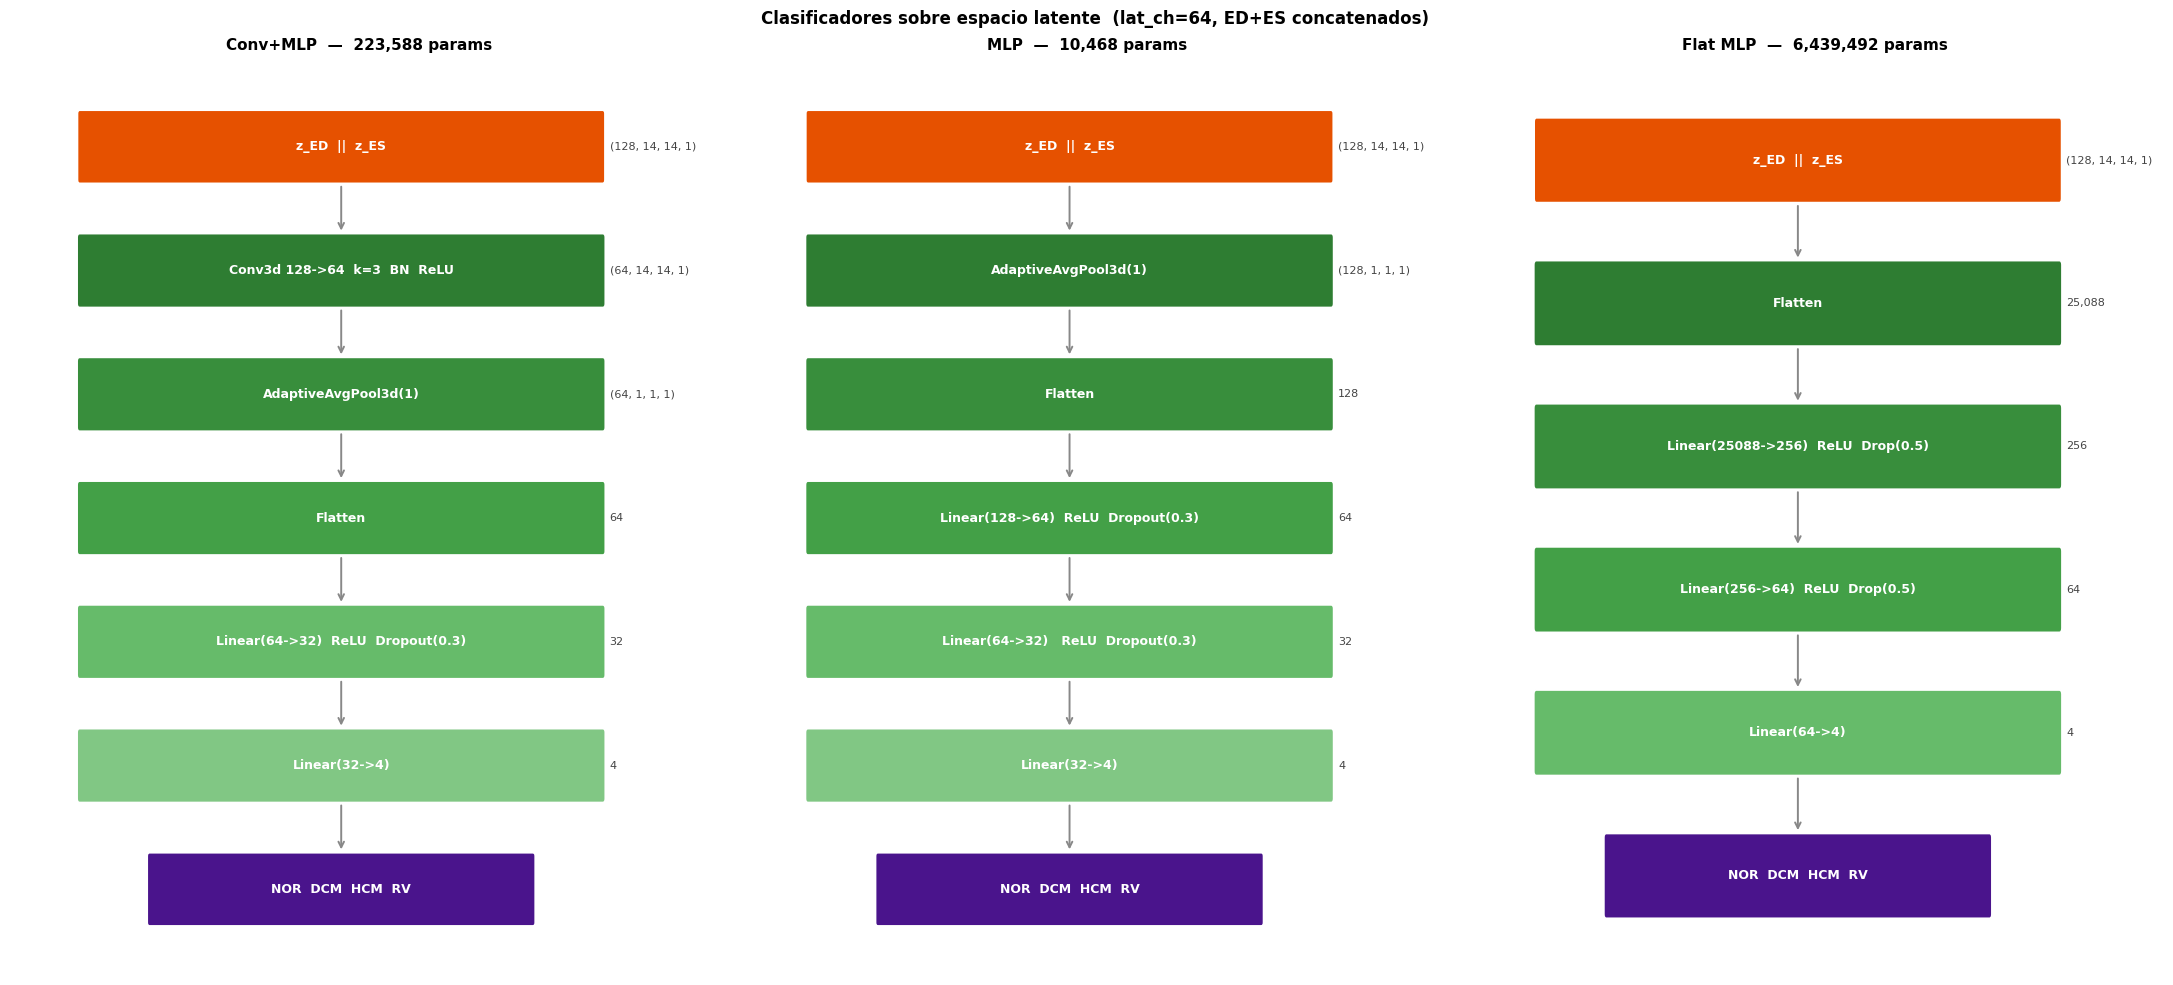

In [15]:
def draw_clf(ax, title, blocks, in_ch):
    n_rows = 1 + len(blocks) + 1
    ax.set_xlim(0, 10)
    ax.set_ylim(-0.5, n_rows * 1.3)
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

    box_h, box_w, x0 = 0.7, 7.5, 1.0
    y = n_rows * 1.3 - 0.9

    COLORS = ['#2e7d32','#388e3c','#43a047','#66bb6a','#81c784','#a5d6a7']

    def box(y, label, shape, color):
        ax.add_patch(mpatches.FancyBboxPatch(
            (x0, y - box_h/2), box_w, box_h,
            boxstyle='round,pad=0.04',
            facecolor=color, edgecolor='white', linewidth=1.5))
        ax.text(x0 + box_w/2, y, label, ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')
        ax.text(x0 + box_w + 0.1, y, shape, ha='left', va='center',
                fontsize=8, color='#444444')

    def arrow(y_top, y_bot):
        ax.annotate('', xy=(x0 + box_w/2, y_bot + box_h/2 + 0.04),
                    xytext=(x0 + box_w/2, y_top - box_h/2 - 0.04),
                    arrowprops=dict(arrowstyle='->', color='#888', lw=1.4))

    ax.add_patch(mpatches.FancyBboxPatch(
        (x0, y - box_h/2), box_w, box_h,
        boxstyle='round,pad=0.04',
        facecolor='#e65100', edgecolor='white', linewidth=2))
    ax.text(x0 + box_w/2, y, 'z_ED  ||  z_ES', ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
    ax.text(x0 + box_w + 0.1, y, f'({in_ch}, 14, 14, 1)',
            ha='left', va='center', fontsize=8, color='#444444')
    y -= 1.3

    for i, (lbl, shp) in enumerate(blocks):
        arrow(y + 1.3, y)
        box(y, lbl, shp, COLORS[min(i, len(COLORS)-1)])
        y -= 1.3

    arrow(y + 1.3, y)
    ax.add_patch(mpatches.FancyBboxPatch(
        (x0 + 1, y - box_h/2), box_w - 2, box_h,
        boxstyle='round,pad=0.04',
        facecolor='#4a148c', edgecolor='white', linewidth=2))
    ax.text(x0 + box_w/2, y, 'NOR  DCM  HCM  RV', ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')


IN_CH    = 128
FLAT_DIM = IN_CH * 14 * 14 * 1   # 25088

blocks_conv_mlp = [
    ('Conv3d 128->64  k=3  BN  ReLU',      '(64, 14, 14, 1)'),
    ('AdaptiveAvgPool3d(1)',                 '(64, 1, 1, 1)'),
    ('Flatten',                              '64'),
    ('Linear(64->32)  ReLU  Dropout(0.3)',  '32'),
    ('Linear(32->4)',                        '4'),
]
blocks_mlp = [
    ('AdaptiveAvgPool3d(1)',                 '(128, 1, 1, 1)'),
    ('Flatten',                              '128'),
    ('Linear(128->64)  ReLU  Dropout(0.3)', '64'),
    ('Linear(64->32)   ReLU  Dropout(0.3)', '32'),
    ('Linear(32->4)',                        '4'),
]
blocks_flat_mlp = [
    ('Flatten',                              f'{FLAT_DIM:,}'),
    (f'Linear({FLAT_DIM}->256)  ReLU  Drop(0.5)', '256'),
    ('Linear(256->64)  ReLU  Drop(0.5)',    '64'),
    ('Linear(64->4)',                        '4'),
]

from train_classifier import CardiacClassifierConvMLP, CardiacClassifierMLP, CardiacClassifierFlatMLP
p_conv = sum(p.numel() for p in CardiacClassifierConvMLP(in_ch=IN_CH).parameters())
p_mlp  = sum(p.numel() for p in CardiacClassifierMLP(in_ch=IN_CH).parameters())
p_flat = sum(p.numel() for p in CardiacClassifierFlatMLP(in_ch=IN_CH).parameters())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 10))
fig.patch.set_facecolor('white')

draw_clf(ax1, f'Conv+MLP  —  {p_conv:,} params',   blocks_conv_mlp, IN_CH)
draw_clf(ax2, f'MLP  —  {p_mlp:,} params',          blocks_mlp,      IN_CH)
draw_clf(ax3, f'Flat MLP  —  {p_flat:,} params',    blocks_flat_mlp, IN_CH)

plt.suptitle('Clasificadores sobre espacio latente  (lat_ch=64, ED+ES concatenados)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Encoder + Clasificador (baseline supervisado)

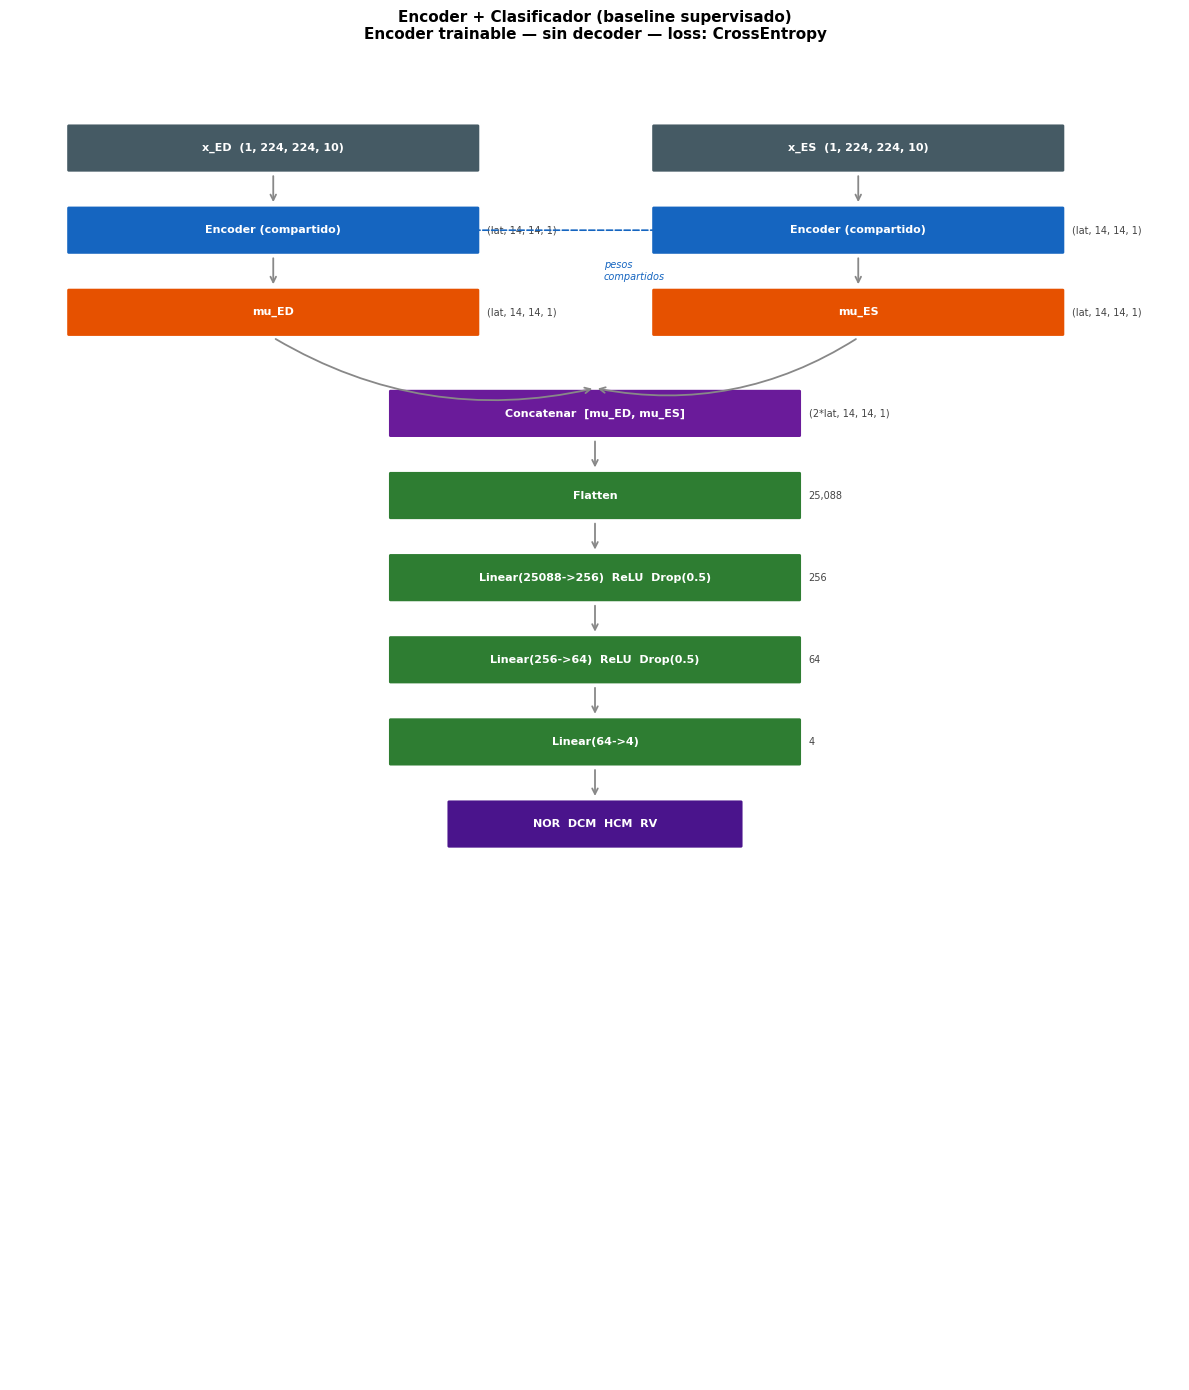

In [19]:
fig, ax = plt.subplots(figsize=(12, 14))
ax.set_xlim(0, 20)
ax.set_ylim(-1, 20)
ax.axis('off')
fig.patch.set_facecolor('white')
ax.set_title('Encoder + Clasificador (baseline supervisado)\nEncoder trainable — sin decoder — loss: CrossEntropy',
             fontsize=11, fontweight='bold', pad=10)

bh, bw = 0.7, 7.0
C_IN  = '#455a64'
C_ENC = '#1565c0'
C_LAT = '#e65100'
C_CAT = '#6a1b9a'
C_CLF = '#2e7d32'
C_OUT = '#4a148c'

def box(ax, x, y, w, label, shape, color):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y - bh/2), w, bh,
        boxstyle='round,pad=0.04',
        facecolor=color, edgecolor='white', linewidth=1.5))
    ax.text(x + w/2, y, label, ha='center', va='center',
            fontsize=8, fontweight='bold', color='white')
    if shape:
        ax.text(x + w + 0.15, y, shape, ha='left', va='center',
                fontsize=7, color='#444')

def arr(ax, x, y1, y2):
    ax.annotate('', xy=(x, y2 + bh/2 + 0.05), xytext=(x, y1 - bh/2 - 0.05),
                arrowprops=dict(arrowstyle='->', color='#888', lw=1.3))

# ── rama ED (izquierda) ──
x_ed = 1.0
box(ax, x_ed, 18.5, bw, 'x_ED  (1, 224, 224, 10)', '', C_IN)
arr(ax, x_ed + bw/2, 18.5, 17.2)
box(ax, x_ed, 17.2, bw, 'Encoder (compartido)', '(lat, 14, 14, 1)', C_ENC)
arr(ax, x_ed + bw/2, 17.2, 15.9)
box(ax, x_ed, 15.9, bw, 'mu_ED', '(lat, 14, 14, 1)', C_LAT)

# ── rama ES (derecha) ──
x_es = 11.0
box(ax, x_es, 18.5, bw, 'x_ES  (1, 224, 224, 10)', '', C_IN)
arr(ax, x_es + bw/2, 18.5, 17.2)
box(ax, x_es, 17.2, bw, 'Encoder (compartido)', '(lat, 14, 14, 1)', C_ENC)
arr(ax, x_es + bw/2, 17.2, 15.9)
box(ax, x_es, 15.9, bw, 'mu_ES', '(lat, 14, 14, 1)', C_LAT)

# ── flechas hacia concatenación ──
x_cat = 10.0
y_cat = 14.3
ax.annotate('', xy=(x_cat, y_cat + bh/2 + 0.05),
            xytext=(x_ed + bw/2, 15.9 - bh/2 - 0.05),
            arrowprops=dict(arrowstyle='->', color='#888', lw=1.3,
                            connectionstyle='arc3,rad=0.2'))
ax.annotate('', xy=(x_cat, y_cat + bh/2 + 0.05),
            xytext=(x_es + bw/2, 15.9 - bh/2 - 0.05),
            arrowprops=dict(arrowstyle='->', color='#888', lw=1.3,
                            connectionstyle='arc3,rad=-0.2'))

# ── concatenación y clasificador ──
box(ax, 6.5, y_cat, bw, 'Concatenar  [mu_ED, mu_ES]', '(2*lat, 14, 14, 1)', C_CAT)

y = y_cat
clf_blocks = [
    ('Flatten', f'{2*LATENT_CH*14*14*1:,}', C_CLF),
    (f'Linear({2*LATENT_CH*14*14}->256)  ReLU  Drop(0.5)', '256', C_CLF),
    ('Linear(256->64)  ReLU  Drop(0.5)', '64', C_CLF),
    ('Linear(64->4)', '4', C_CLF),
]
for lbl, shp, col in clf_blocks:
    arr(ax, 10.0, y, y - 1.3)
    y -= 1.3
    box(ax, 6.5, y, bw, lbl, shp, col)

arr(ax, 10.0, y, y - 1.3)
y -= 1.3
box(ax, 7.5, y, bw - 2, 'NOR  DCM  HCM  RV', '', C_OUT)

# nota pesos compartidos
ax.text(10.15, 16.55, 'pesos\ncompartidos', ha='left', va='center',
        fontsize=7, color='#1565c0', style='italic')
ax.annotate('', xy=(x_es + 0.3, 17.2), xytext=(x_ed + bw - 0.3, 17.2),
            arrowprops=dict(arrowstyle='<->', color='#1565c0', lw=1.2,
                            linestyle='dashed'))

plt.tight_layout()
plt.show()